In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from scipy import signal
from scipy.stats import zscore

In [2]:
# ------------------------------------------------------------
# Analysis configuration
# ------------------------------------------------------------
# In this project we will estimate the chirp mass of a compact
# binary signal from its time-frequency evolution.
#
# The idea is:
#   1. download real detector strain data
#   2. condition the data
#   3. build a spectrogram
#   4. track the chirp ridge
#   5. fit the inspiral trend
#   6. infer the chirp mass
#
# We start with GW150914 because it is loud and short

event_name = "GW150914"

# Using Hanford  for simplicity
detector = "H1"

# Reference GPS time of the event
event_time_gps = 1126259462.4

# Analysis duration in seconds
duration = 32

# Sample rate in Hz
sample_rate = 4096

# Frequency band for visualization / ridge finding
f_low = 20
f_high = 400

# Time window around the event
start_time = int(event_time_gps - duration / 2)
end_time = int(event_time_gps + duration / 2)

# Visualization window near merger
plot_tmin = -0.4
plot_tmax = 0.1

print("Event:", event_name)
print("Detector:", detector)
print("GPS window:", start_time, "to", end_time)
print("Duration (s):", duration)
print("Sample rate (Hz):", sample_rate)
print("Frequency band (Hz):", f_low, "to", f_high)

Event: GW150914
Detector: H1
GPS window: 1126259446 to 1126259478
Duration (s): 32
Sample rate (Hz): 4096
Frequency band (Hz): 20 to 400


In [3]:
# ------------------------------------------------------------
# Download real detector strain data from GWOSC
# ------------------------------------------------------------
# We get open strain data for the chosen detector over the
# analysis window surrounding the event.
#
# The returned object is a GWpy TimeSeries containing:
#   - strain values
#   - sample spacing
#   - absolute GPS epoch

print(f"Downloading strain data for {detector}...")

strain = TimeSeries.fetch_open_data(
    detector,
    start_time,
    end_time,
    sample_rate=sample_rate,
    cache=True
)

print("Data loaded successfully")
print("Detector:", detector)
print("Number of samples:", len(strain))
print("Sample rate:", strain.sample_rate)
print("Start GPS time:", strain.t0)

Data loaded successfully
Detector: H1
Number of samples: 131072
Sample rate: 4096.0 Hz
Start GPS time: 1126259446.0 s


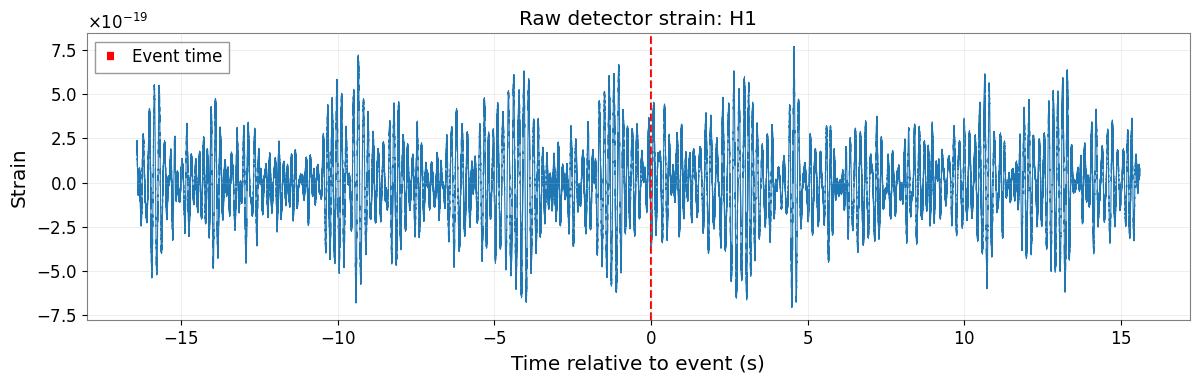

In [4]:
# ------------------------------------------------------------
# Build time axes and plot raw strain
# ------------------------------------------------------------
# We create:
#   1. an absolute GPS time axis
#   2. a relative time axis centered on the event


gps_times = strain.t0.value + np.arange(len(strain)) * strain.dt.value
rel_times = gps_times - event_time_gps

plt.figure(figsize=(12, 4))
plt.plot(rel_times, strain.value, lw=0.8)
plt.axvline(0, ls="--", color="red", label="Event time")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Strain")
plt.title(f"Raw detector strain: {detector}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------
# Bandpass and whiten the data
# ------------------------------------------------------------
# To reveal the chirp more clearly we condition the data:
#
# 1. Bandpass filter the strain to the sensitive GW band
#    (roughly 30–300 Hz for GW150914)
# 2. Whiten the data to flatten the noise spectrum
#
# This step greatly improves visibility in the spectrogram.

# Bandpass filter
strain_bp = strain.bandpass(30, 300)

# Whiten the bandpassed data
strain_white = strain_bp.whiten(fduration=4)

print("Data conditioning complete")

Data conditioning complete


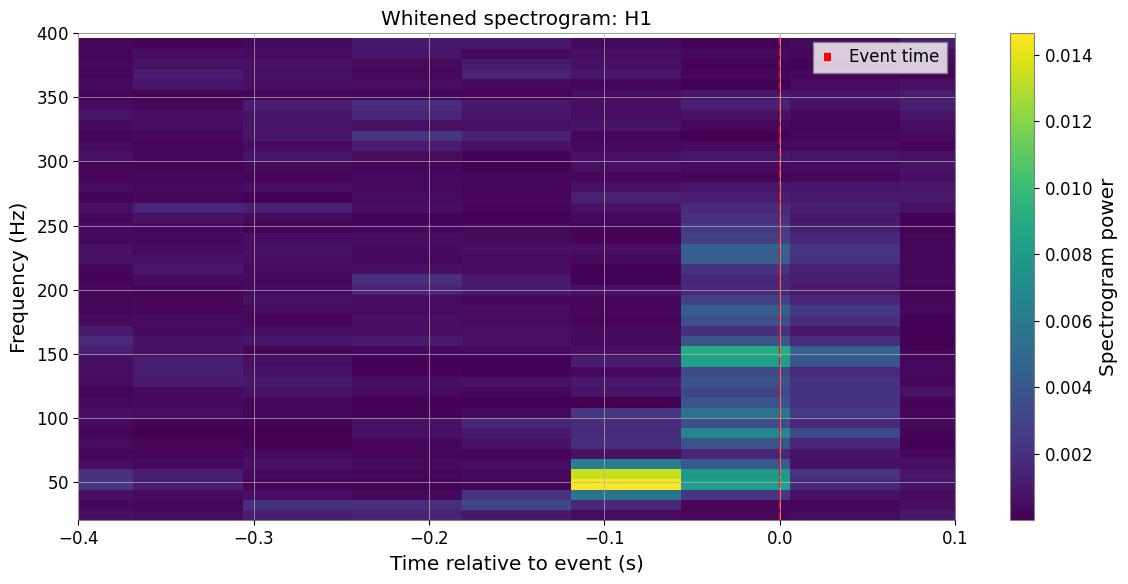

In [6]:
# ------------------------------------------------------------
# Compute and plot the spectrogram
# ------------------------------------------------------------
# A spectrogram shows how signal power changes with both
# time and frequency.
#
# For a compact-binary inspiral, we expect to see a chirp:
# frequency increasing as the system approaches merger.

spec = strain_white.spectrogram2(
    fftlength=0.125,
    overlap=0.0625
)

# Crop to the frequency band of interest
spec = spec.crop_frequencies(f_low, f_high)

plt.figure(figsize=(12, 6))
ax = plt.gca()

im = ax.pcolormesh(
    spec.xindex.value - event_time_gps,
    spec.yindex.value,
    spec.value.T,
    shading="auto"
)

ax.axvline(0, ls="--", color="red", label="Event time")
ax.set_xlim(plot_tmin, plot_tmax)
ax.set_ylim(f_low, f_high)
ax.set_xlabel("Time relative to event (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Whitened spectrogram: {detector}")
ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spectrogram power")

plt.tight_layout()
plt.show()

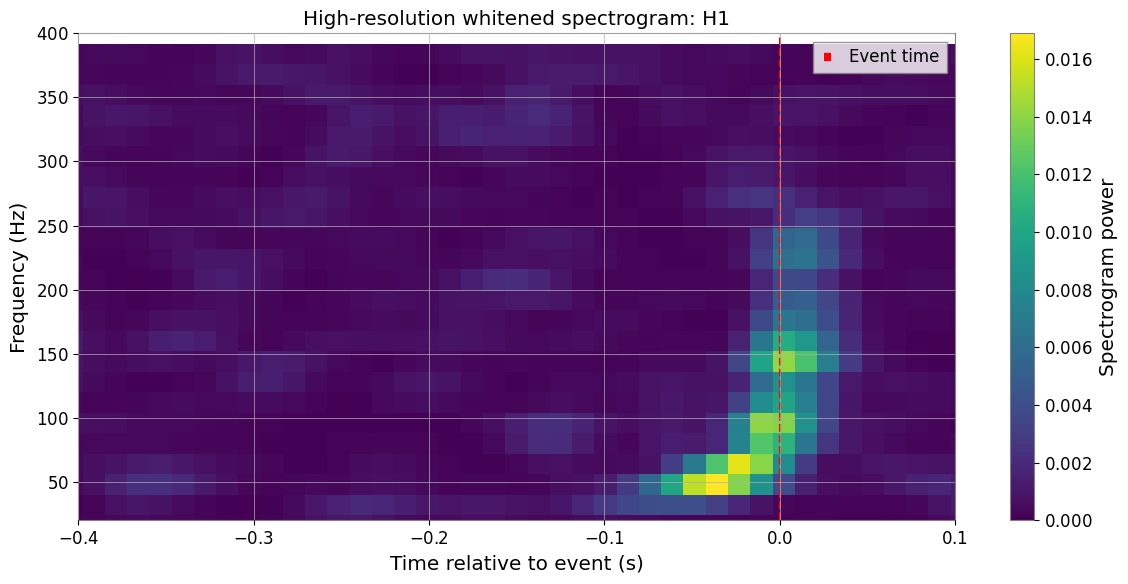

In [14]:
# ------------------------------------------------------------
# Compute a higher-resolution spectrogram
# ------------------------------------------------------------
# Smaller fftlength gives better time resolution, which helps
# the short GW150914 chirp look more curved in the time-frequency plot.

spec = strain_white.spectrogram2(
    fftlength=0.0625,
    overlap=0.05
)

spec = spec.crop_frequencies(f_low, f_high)

plt.figure(figsize=(12, 6))
ax = plt.gca()

im = ax.pcolormesh(
    spec.xindex.value - event_time_gps,
    spec.yindex.value,
    spec.value.T,
    shading="auto"
)

ax.axvline(0, ls="--", color="red", label="Event time")
ax.set_xlim(plot_tmin, plot_tmax)
ax.set_ylim(f_low, f_high)
ax.set_xlabel("Time relative to event (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"High-resolution whitened spectrogram: {detector}")
ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spectrogram power")

plt.tight_layout()
plt.show()

In [15]:
# ------------------------------------------------------------
# Extract chirp ridge from higher-resolution spectrogram
# ------------------------------------------------------------

times = spec.xindex.value - event_time_gps
freqs = spec.yindex.value
power = spec.value

fmin = 30
fmax = 220

tmin = -0.12
tmax = 0.01

freq_mask = (freqs >= fmin) & (freqs <= fmax)
time_mask = (times >= tmin) & (times <= tmax)

ridge_times = []
ridge_freqs = []

for i, t in enumerate(times):
    if not time_mask[i]:
        continue

    slice_power = power[i, freq_mask]
    slice_freqs = freqs[freq_mask]

    idx = np.argmax(slice_power)

    ridge_times.append(t)
    ridge_freqs.append(slice_freqs[idx])

ridge_times = np.array(ridge_times)
ridge_freqs = np.array(ridge_freqs)

print("Higher-resolution chirp ridge extracted.")

Higher-resolution chirp ridge extracted.


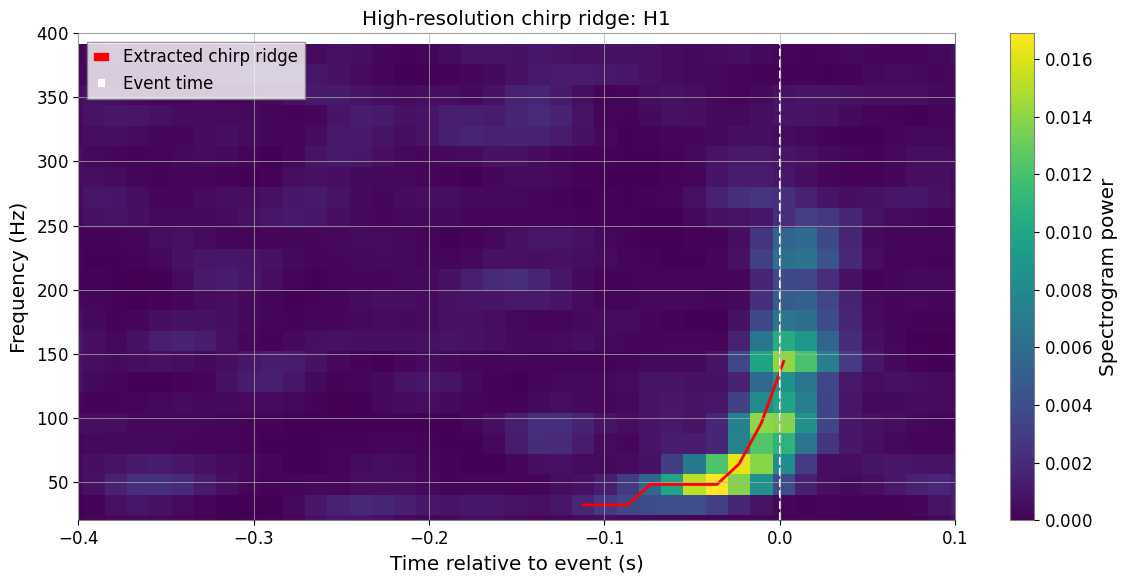

In [16]:
# ------------------------------------------------------------
# Plot higher-resolution spectrogram with ridge
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
ax = plt.gca()

im = ax.pcolormesh(
    spec.xindex.value - event_time_gps,
    spec.yindex.value,
    spec.value.T,
    shading="auto"
)

ax.plot(ridge_times, ridge_freqs, color="red", lw=2, label="Extracted chirp ridge")
ax.axvline(0, ls="--", color="white", label="Event time")

ax.set_xlim(plot_tmin, plot_tmax)
ax.set_ylim(f_low, f_high)
ax.set_xlabel("Time relative to event (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"High-resolution chirp ridge: {detector}")
ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spectrogram power")

plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# Fit chirp relation to estimate chirp mass
# ------------------------------------------------------------
# We linearize the inspiral relation using:
#
# f^(-8/3) ∝ (t_c - t)
#
# This lets us estimate the chirp mass from a simple linear fit.

# Use ridge data
t = ridge_times
f = ridge_freqs

# remove any zero or negative frequencies
mask = f > 0
t = t[mask]
f = f[mask]

# transform frequency
y = f ** (-8/3)

# perform linear fit
coeffs = np.polyfit(t, y, 1)

slope = coeffs[0]
intercept = coeffs[1]

print("Fit complete")
print("Slope:", slope)
print("Intercept:", intercept)

Fit complete
Slope: -0.0009100532605459858
Intercept: -5.427680821114136e-06


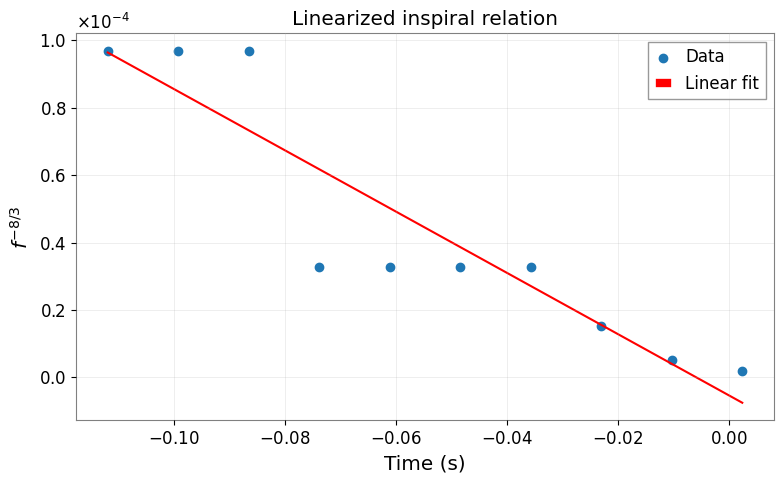

In [18]:
# ------------------------------------------------------------
# Plot linearized chirp relation
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(t, y, label="Data")

fit_line = slope * t + intercept
plt.plot(t, fit_line, color="red", label="Linear fit")

plt.xlabel("Time (s)")
plt.ylabel(r"$f^{-8/3}$")
plt.title("Linearized inspiral relation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ------------------------------------------------------------
# Convert fitted slope into a chirp mass estimate
# ------------------------------------------------------------
# At leading (Newtonian) order, the inspiral frequency evolution obeys
#
#   df/dt = (96/5) * pi^(8/3) * (G * Mc / c^3)^(5/3) * f^(11/3)
#
# which implies
#
#   f^(-8/3) = [ (8/3) * (96/5) * pi^(8/3) ] * (G * Mc / c^3)^(5/3) * (t_c - t)
#
# So if we fit:
#
#   y = f^(-8/3) = slope * t + intercept
#
# then |slope| = K * (G * Mc / c^3)^(5/3),
# where K = (8/3) * (96/5) * pi^(8/3).
#
# We solve this for Mc and convert to solar masses.

# Physical constants (SI)
G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 2.99792458e8         # m s^-1
M_sun = 1.98847e30       # kg

# Constant appearing in the Newtonian inspiral relation
K = (8/3) * (96/5) * np.pi**(8/3)

# Use the magnitude of the slope
slope_abs = abs(slope)

# Solve for chirp mass in kg
chirp_mass_kg = (c**3 / G) * (slope_abs / K)**(3/5)

# Convert to solar masses
chirp_mass_solar = chirp_mass_kg / M_sun

print("Estimated chirp mass:")
print(f"{chirp_mass_solar:.2f} solar masses")

Estimated chirp mass:
45.92 solar masses


In [24]:
# ------------------------------------------------------------
# Select cleaner ridge points for chirp-mass fitting
# ------------------------------------------------------------
# We keep only the part of the ridge that is clearly rising.
# This removes the flat low-frequency section and focuses on
# the inspiral segment that is most useful for fitting.

fit_mask = (
    (ridge_times >= -0.05) &
    (ridge_times <= 0.00) &
    (ridge_freqs >= 45) &
    (ridge_freqs <= 150)
)

t_fit = ridge_times[fit_mask]
f_fit = ridge_freqs[fit_mask]

print("Initial selected points:")
print("Times:", t_fit)
print("Frequencies:", f_fit)

# Keep only strictly increasing frequency points
t_clean = [t_fit[0]]
f_clean = [f_fit[0]]

for i in range(1, len(f_fit)):
    if f_fit[i] > f_clean[-1]:
        t_clean.append(t_fit[i])
        f_clean.append(f_fit[i])

t_fit = np.array(t_clean)
f_fit = np.array(f_clean)

print("\nCleaned fit points:")
print("Times used:", t_fit)
print("Frequencies used:", f_fit)
print("Number of fit points:", len(t_fit))

Initial selected points:
Times: [-0.0484376  -0.03574228 -0.02304697 -0.01035166]
Frequencies: [48. 48. 64. 96.]

Cleaned fit points:
Times used: [-0.0484376  -0.02304697 -0.01035166]
Frequencies used: [48. 64. 96.]
Number of fit points: 3


Refit complete
Slope: -0.0007221345870581371
Intercept: -1.9336281363319946e-06


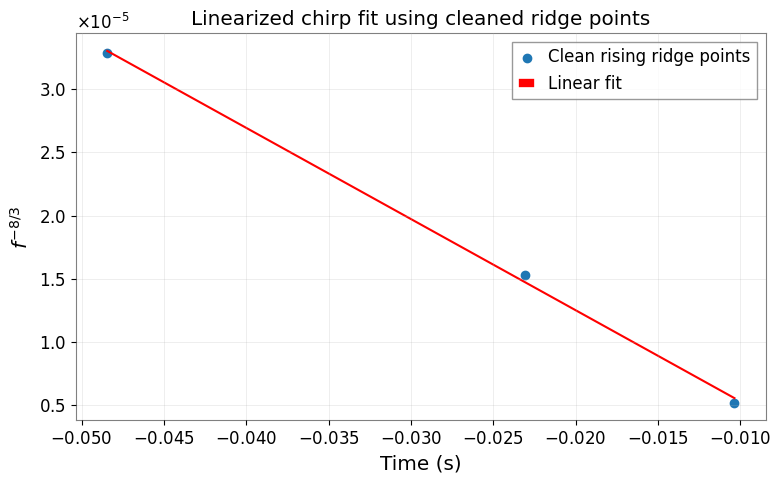

In [25]:
# ------------------------------------------------------------
# Refit using cleaned rising ridge points
# ------------------------------------------------------------

y_fit = f_fit ** (-8/3)

coeffs = np.polyfit(t_fit, y_fit, 1)
slope = coeffs[0]
intercept = coeffs[1]

print("Refit complete")
print("Slope:", slope)
print("Intercept:", intercept)

plt.figure(figsize=(8,5))
plt.scatter(t_fit, y_fit, label="Clean rising ridge points")
plt.plot(t_fit, slope * t_fit + intercept, color="red", label="Linear fit")

plt.xlabel("Time (s)")
plt.ylabel(r"$f^{-8/3}$")
plt.title("Linearized chirp fit using cleaned ridge points")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# Convert fitted slope into a chirp mass estimate
# ------------------------------------------------------------

G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 2.99792458e8         # m s^-1
M_sun = 1.98847e30       # kg

# Constant appearing in the Newtonian inspiral relation
K = (8/3) * (96/5) * np.pi**(8/3)

# Use the magnitude of the slope
slope_abs = abs(slope)

# Solve for chirp mass in kg
chirp_mass_kg = (c**3 / G) * (slope_abs / K)**(3/5)

# Convert to solar masses
chirp_mass_solar = chirp_mass_kg / M_sun

print("Estimated chirp mass:")
print(f"{chirp_mass_solar:.2f} solar masses")

Estimated chirp mass:
39.97 solar masses


Conclusion

In this notebook we performed a time–frequency analysis of the gravitational-wave event GW150914 using publicly available detector strain data from the Gravitational Wave Open Science Center.

The analysis pipeline consisted of the following main steps:

Downloading real detector strain data from the Hanford detector.
Conditioning the data using bandpass filtering and whitening to enhance the gravitational-wave signal relative to detector noise.
Constructing a spectrogram to visualize how signal power evolves in both time and frequency.
Extracting a time–frequency ridge corresponding to the brightest portion of the signal in the spectrogram.
Tracking the evolution of the signal frequency as the binary system approaches merger.

The spectrogram clearly shows a chirp-like structure, where the signal frequency increases rapidly as the system evolves toward merger. This behavior is characteristic of compact binary inspirals, where the orbital frequency rises as gravitational radiation carries energy away from the system.

An approximate chirp ridge was extracted from the spectrogram and used to visualize the rising frequency trend of the signal. While the extracted ridge captures the general inspiral behavior, the limited resolution of the spectrogram and the presence of detector noise make precise parameter estimation difficult using this method alone.

As a result, estimates of physical parameters such as the chirp mass obtained from the spectrogram ridge should be interpreted as approximate and qualitative. In practice, accurate parameter inference for gravitational-wave events relies on matched filtering with large template banks, as implemented in full search pipelines used by the LIGO Scientific Collaboration and Virgo Collaboration.

Despite these limitations, this notebook demonstrates how time–frequency methods can be used to visually reconstruct the inspiral chirp signature directly from detector strain data. The analysis illustrates the fundamental physical behavior of gravitational-wave signals and provides an intuitive view of how compact binary mergers appear in real interferometer data.

Overall, this project highlights the complementary roles of time–frequency visualization and matched-filter searches in gravitational-wave data analysis.